In [12]:
import os
import struct
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


OUT_DIR = "lab_out"
os.makedirs(OUT_DIR, exist_ok=True)

img = Image.open("sar_1_gray.jpg").convert("L")
I = np.array(img, dtype=np.uint8)

H, W = I.shape
print("Размер изображения:", H, W)

I.tofile(os.path.join(OUT_DIR, "sar_1_gray.raw"))
np.savetxt(os.path.join(OUT_DIR, "sar_1_gray.txt"), I, fmt="%d")

Размер изображения: 400 600


In [13]:
def haar_1d(x):
    a = x[..., 0::2].astype(np.int32)
    b = x[..., 1::2].astype(np.int32)
    return (a + b) // 2, a - b

def haar_2d(img):
    a, d = haar_1d(img)
    LL, LH = haar_1d(a.T)
    HL, HH = haar_1d(d.T)
    return LL.T, LH.T, HL.T, HH.T

LL, LH, HL, HH = haar_2d(I)



In [14]:
def haar_1d(x):
    a = x[..., 0::2].astype(np.int32)
    b = x[..., 1::2].astype(np.int32)
    return (a + b) // 2, a - b

def haar_2d(img):
    a, d = haar_1d(img)
    LL, LH = haar_1d(a.T)
    HL, HH = haar_1d(d.T)
    return LL.T, LH.T, HL.T, HH.T

LL, LH, HL, HH = haar_2d(I)


In [15]:
def quantize(x, q=4):
    m = np.max(np.abs(x))
    if m == 0:
        return np.zeros_like(x, dtype=np.int8), 1.0
    step = m / q
    qx = np.floor(np.abs(x) / step)
    qx = np.clip(qx, 0, q - 1)
    return (qx * np.sign(x)).astype(np.int8), step

qLH, stepLH = quantize(LH, 4)
qHL, stepHL = quantize(HL, 4)
qHH, stepHH = quantize(HH, 4)


In [16]:
def rle(arr):
    arr = arr.ravel()
    res = []
    val = int(arr[0])
    cnt = 1
    for x in arr[1:]:
        x = int(x)
        if x == val:
            cnt += 1
        else:
            res.append((val, cnt))
            val = x
            cnt = 1
    res.append((val, cnt))
    return res

rle_LH = rle(qLH)
rle_HL = rle(qHL)
rle_HH = rle(qHH)


In [17]:
with open(os.path.join(OUT_DIR, "haar_rle.bin"), "wb") as f:
    f.write(b"HAR1")
    f.write(struct.pack("<II", H, W))

    # LL
    LL16 = LL.astype(np.int16)
    f.write(struct.pack("<II", *LL16.shape))
    f.write(LL16.tobytes())

    # LH, HL, HH (RLE)
    for runs in (rle_LH, rle_HL, rle_HH):
        f.write(struct.pack("<I", len(runs)))
        for v, c in runs:
            f.write(struct.pack("<bI", v, c))


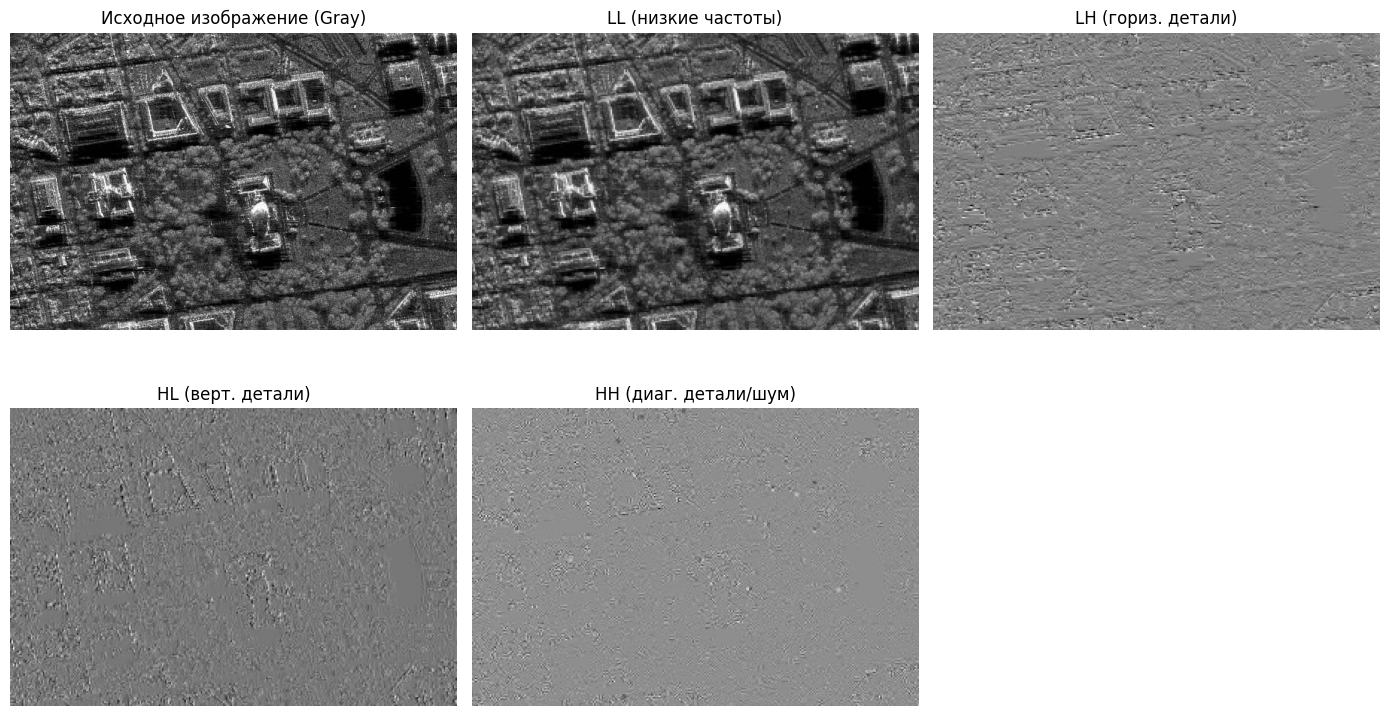

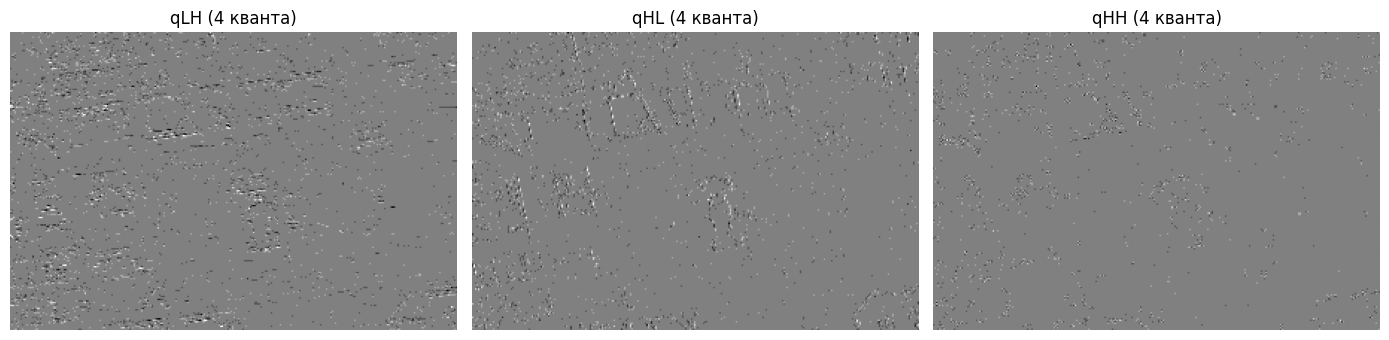

Готово: изображения выведены, файлы сохранены в lab_out


In [18]:
def show_gray(ax, im, title):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

def show_zero_centered(ax, im, title):
    # чтобы детали были видны: сдвигаем к середине и нормируем
    im = im.astype(np.float32)
    m = np.max(np.abs(im)) if np.max(np.abs(im)) != 0 else 1.0
    vis = (im / m + 1) / 2  # [-1..1] -> [0..1]
    ax.imshow(vis, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.figure(figsize=(14, 8))
ax = plt.subplot(2, 3, 1)
show_gray(ax, I, "Исходное изображение (Gray)")

ax = plt.subplot(2, 3, 2)
show_gray(ax, LL, "LL (низкие частоты)")

ax = plt.subplot(2, 3, 3)
show_zero_centered(ax, LH, "LH (гориз. детали)")

ax = plt.subplot(2, 3, 4)
show_zero_centered(ax, HL, "HL (верт. детали)")

ax = plt.subplot(2, 3, 5)
show_zero_centered(ax, HH, "HH (диаг. детали/шум)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
ax = plt.subplot(1, 3, 1)
show_zero_centered(ax, qLH, "qLH (4 кванта)")

ax = plt.subplot(1, 3, 2)
show_zero_centered(ax, qHL, "qHL (4 кванта)")

ax = plt.subplot(1, 3, 3)
show_zero_centered(ax, qHH, "qHH (4 кванта)")
plt.tight_layout()
plt.show()

print("Готово: изображения выведены, файлы сохранены в", OUT_DIR)

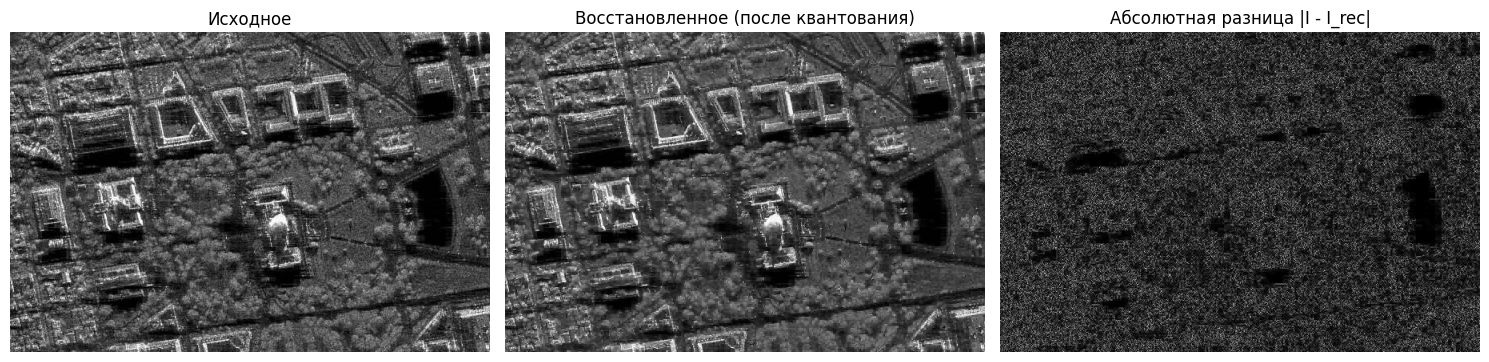

MSE = 192.3384
PSNR = 25.29 dB


In [20]:


def ihaar_1d_float(approx, detail):
    approx = approx.astype(np.float32)
    detail = detail.astype(np.float32)
    a = approx + detail / 2.0
    b = approx - detail / 2.0
    out = np.empty((approx.shape[0], approx.shape[1] * 2), dtype=np.float32)
    out[:, 0::2] = a
    out[:, 1::2] = b
    return out

def ihaar_2d_float(LL, LH, HL, HH):
    A = ihaar_1d_float(LL.T, LH.T).T   
    D = ihaar_1d_float(HL.T, HH.T).T   
    X = ihaar_1d_float(A, D)
    return X

def dequantize_signed_mag(q, step):
    q = q.astype(np.float32)
    # центр квантового интервала: (|q| + 0.5) * step
    return np.sign(q) * (np.abs(q) + 0.5) * step

dLH = dequantize_signed_mag(qLH, stepLH)
dHL = dequantize_signed_mag(qHL, stepHL)
dHH = dequantize_signed_mag(qHH, stepHH)

I_rec = ihaar_2d_float(LL, dLH, dHL, dHH)
I_rec = np.clip(np.rint(I_rec), 0, 255).astype(np.uint8)

def mse(a, b):
    a = a.astype(np.float32)
    b = b.astype(np.float32)
    return np.mean((a - b) ** 2)

def psnr(a, b, maxv=255.0):
    m = mse(a, b)
    if m == 0:
        return float("inf")
    return 10 * np.log10((maxv ** 2) / m)

m = mse(I, I_rec)
p = psnr(I, I_rec)

diff = np.abs(I.astype(np.int16) - I_rec.astype(np.int16)).astype(np.uint8)

plt.figure(figsize=(15, 5))
ax = plt.subplot(1, 3, 1)
ax.imshow(I, cmap="gray"); ax.set_title("Исходное"); ax.axis("off")

ax = plt.subplot(1, 3, 2)
ax.imshow(I_rec, cmap="gray"); ax.set_title("Восстановленное (после квантования)"); ax.axis("off")

ax = plt.subplot(1, 3, 3)
ax.imshow(diff, cmap="gray"); ax.set_title("Абсолютная разница |I - I_rec|"); ax.axis("off")

plt.tight_layout()
plt.show()

print(f"MSE = {m:.4f}")
print(f"PSNR = {p:.2f} dB")
